# Project: Image Compression with SVD

## 0. Overview

**Problem statement:** A grayscale image is a matrix of pixel intensities. Most of the visual information in natural images lives in a low-dimensional subspace — the leading singular vectors capture large-scale structure (edges, gradients, textures) while trailing ones encode noise. This project uses the SVD to compress images by retaining only the top-k singular components, then analyzes the tradeoff between compression ratio and visual quality.

**Concepts from this Part:**
- ch173: SVD decomposition M = UΣVᵀ and truncated approximation
- ch175: Dimensionality reduction and effective rank
- ch179: Numerical stability and the pseudoinverse
- ch158–ch159: Determinants and matrix rank as measures of information content

**Expected output:** Visual comparison of original vs compressed images at multiple ranks; quantitative plots of compression ratio, reconstruction error (Frobenius norm), and PSNR vs rank k.

**Difficulty:** Intermediate. **Estimated time:** 45–75 minutes.

---

## 1. Setup

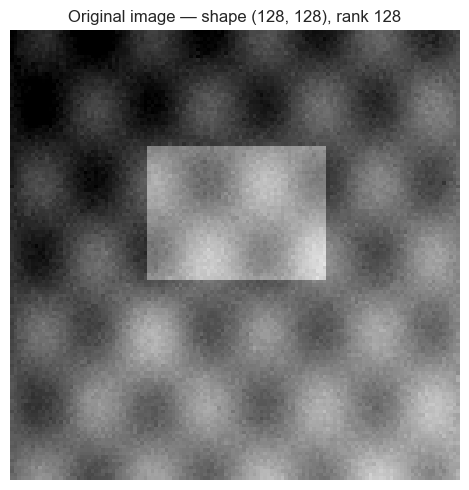

Image shape: (128, 128)
Pixel value range: [0.000, 0.896]
Full storage: 16384 floats


In [1]:
# --- Setup: Imports, constants, and image generation ---

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# --- Generate a synthetic test image (no external data needed) ---
# We use a combination of smooth gradients and structured patterns
# to mimic the low-rank structure of natural images.

def make_test_image(height=128, width=128, seed=42):
    """
    Generate a synthetic grayscale image with:
    - Smooth gradient background (very low rank)
    - Several geometric shapes (low rank)
    - Mild noise (full rank but low amplitude)
    
    Returns:
        img: float array, shape (height, width), values in [0, 1]
    """
    rng = np.random.default_rng(seed)
    y, x = np.mgrid[0:height, 0:width]
    yr = y / height
    xr = x / width

    # Smooth gradient (rank-2 structure)
    img = 0.4 * yr + 0.3 * xr

    # Sinusoidal pattern (rank-2 structure)
    img += 0.15 * np.sin(8 * np.pi * xr) * np.cos(6 * np.pi * yr)

    # Hard edges (a rectangle)
    mask = (yr > 0.25) & (yr < 0.55) & (xr > 0.3) & (xr < 0.7)
    img[mask] += 0.3

    # Soft disk
    cy, cx = 0.7, 0.3
    dist = np.sqrt((yr - cy)**2 + (xr - cx)**2)
    img += 0.2 * np.exp(-50 * dist**2)

    # Mild random noise
    img += rng.standard_normal((height, width)) * 0.02

    # Clip to [0, 1]
    img = np.clip(img, 0, 1)
    return img


IMAGE = make_test_image(height=128, width=128)

# Display the original image
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(IMAGE, cmap='gray', vmin=0, vmax=1)
ax.set_title(f'Original image — shape {IMAGE.shape}, rank {np.linalg.matrix_rank(IMAGE)}')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {IMAGE.shape}")
print(f"Pixel value range: [{IMAGE.min():.3f}, {IMAGE.max():.3f}]")
print(f"Full storage: {IMAGE.size} floats")

## 2. Stage 1 — SVD Decomposition and Singular Value Analysis

90.0% energy: rank   1, storage    257 floats (63.8x compression)
95.0% energy: rank   2, storage    514 floats (31.9x compression)
99.0% energy: rank   3, storage    771 floats (21.3x compression)
99.9% energy: rank  27, storage   6939 floats (2.4x compression)


C:\Users\user\AppData\Local\Temp\ipykernel_26960\1536787050.py:65: UserWarning: Glyph 8855 (\N{CIRCLED TIMES}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8855 (\N{CIRCLED TIMES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


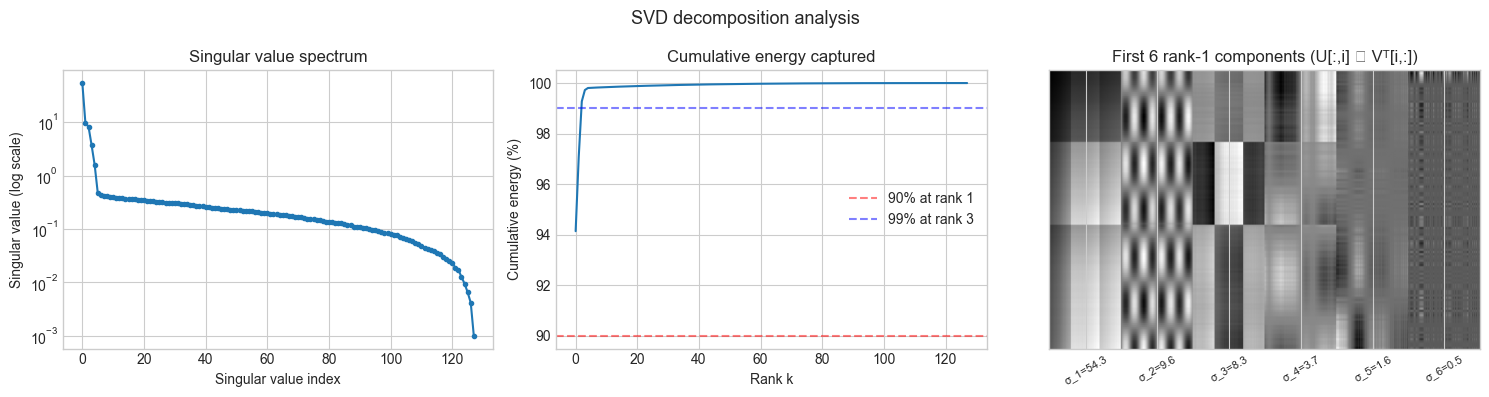

In [4]:
# --- Stage 1: Decompose and analyze the singular value spectrum ---
#
# Every image has a singular value spectrum that reveals how much
# information is concentrated in each rank-1 component.
# Natural images and smooth synthetic images have fast-decaying spectra.
# Pure noise has a flat spectrum.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Compute full SVD: IMAGE = U @ diag(s) @ Vt
U, s, Vt = np.linalg.svd(IMAGE, full_matrices=False)
# U: (128, 128), s: (128,), Vt: (128, 128)

# How much energy (squared Frobenius norm) is captured by top-k components?
total_energy = np.sum(s**2)
cumulative_energy = np.cumsum(s**2) / total_energy

# Find ranks for various energy thresholds
for threshold in [0.90, 0.95, 0.99, 0.999]:
    rank_needed = int(np.searchsorted(cumulative_energy, threshold)) + 1
    storage = rank_needed * (IMAGE.shape[0] + IMAGE.shape[1] + 1)
    compression = IMAGE.size / storage
    print(f"{threshold*100:.1f}% energy: rank {rank_needed:3d}, "
          f"storage {storage:6d} floats ({compression:.1f}x compression)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Singular value spectrum
axes[0].semilogy(s, 'o-', markersize=3)
axes[0].set_xlabel('Singular value index')
axes[0].set_ylabel('Singular value (log scale)')
axes[0].set_title('Singular value spectrum')

# Cumulative energy
axes[1].plot(cumulative_energy * 100)
for thr, color in [(0.90, 'red'), (0.99, 'blue')]:
    r = int(np.searchsorted(cumulative_energy, thr)) + 1
    axes[1].axhline(thr * 100, color=color, linestyle='--', alpha=0.5, label=f'{thr*100:.0f}% at rank {r}')
axes[1].set_xlabel('Rank k')
axes[1].set_ylabel('Cumulative energy (%)')
axes[1].set_title('Cumulative energy captured')
axes[1].legend()

# First few singular vectors visualized as images
n_show = 6
combo = np.zeros((IMAGE.shape[0], IMAGE.shape[1] * n_show))
for i in range(n_show):
    component = np.outer(U[:, i], Vt[i, :])  # rank-1 matrix
    col_start = i * IMAGE.shape[1]
    col_end = col_start + IMAGE.shape[1]
    component_range = component.max() - component.min()
    norm_comp = (component - component.min()) / (component_range + 1e-9)
    combo[:, col_start:col_end] = norm_comp

axes[2].imshow(combo, cmap='gray', aspect='auto')
axes[2].set_title(f'First {n_show} rank-1 components (U[:,i] ⊗ Vᵀ[i,:])')
axes[2].set_xticks([(i + 0.5) * IMAGE.shape[1] for i in range(n_show)])
axes[2].set_xticklabels([f'σ_{i+1}={s[i]:.1f}' for i in range(n_show)], rotation=30, fontsize=8)
axes[2].set_yticks([])

plt.suptitle('SVD decomposition analysis', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Stage 2 — Truncated SVD Reconstruction

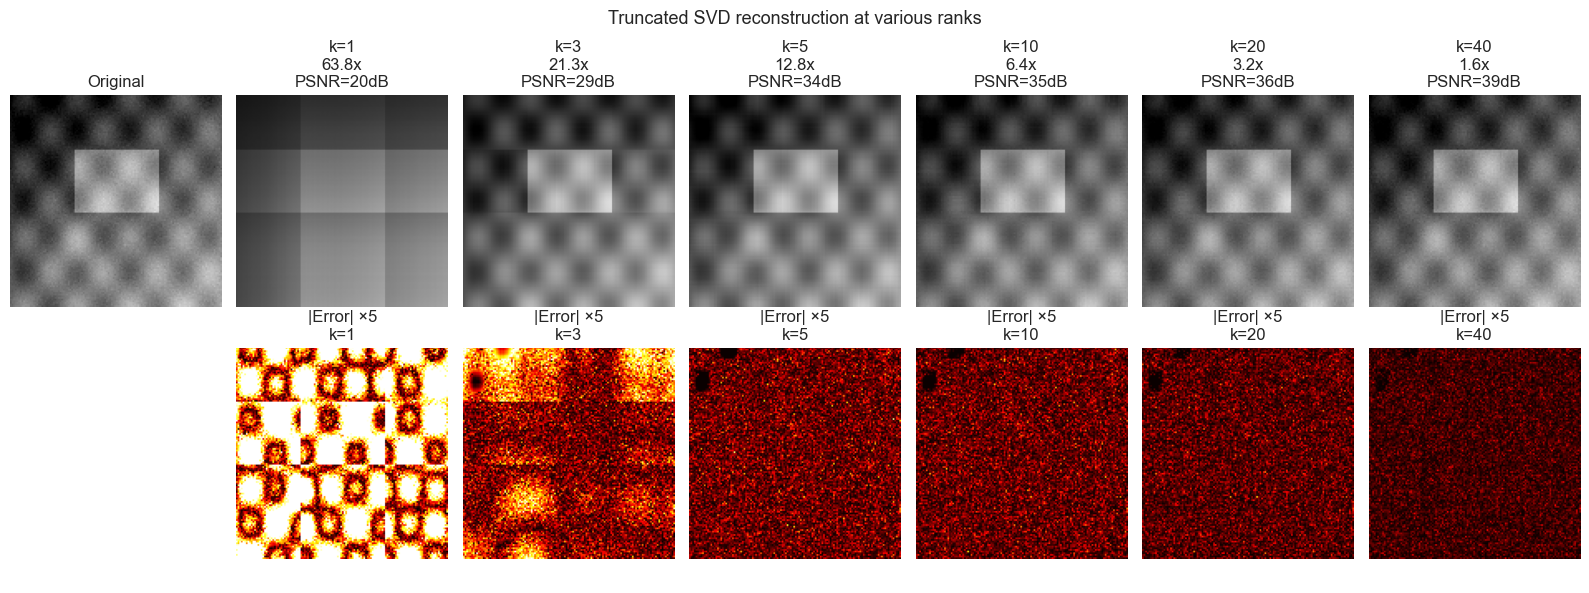

In [5]:
# --- Stage 2: Reconstruct images at different ranks and measure quality ---
#
# Truncated SVD: keep only top-k singular values/vectors.
# Reconstruction: M_k = U[:, :k] @ diag(s[:k]) @ Vt[:k, :]
#
# Quality metrics:
#   - Frobenius error: ‖M - M_k‖_F / ‖M‖_F  (relative)
#   - PSNR (Peak Signal-to-Noise Ratio): 20·log10(1 / RMSE), higher = better
#   - Compression ratio: total_pixels / stored_values

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def truncated_svd_reconstruct(U, s, Vt, k):
    """
    Reconstruct matrix using top-k singular components.
    
    Args:
        U:   left singular vectors, (m, min(m,n))
        s:   singular values, (min(m,n),)
        Vt:  right singular vectors transposed, (min(m,n), n)
        k:   number of components to retain
    Returns:
        M_k: rank-k approximation, (m, n)
    """
    # Equivalent to: sum of k outer products, each scaled by s[i]
    return U[:, :k] @ (np.diag(s[:k]) @ Vt[:k, :])

def psnr(original, reconstructed):
    """Peak Signal-to-Noise Ratio (dB). Higher = better quality."""
    mse = np.mean((original - reconstructed)**2)
    if mse == 0:
        return np.inf
    return 20 * np.log10(1.0 / np.sqrt(mse))  # max pixel value = 1

def compression_ratio(image, k):
    """Ratio of original storage to compressed storage."""
    m, n = image.shape
    original_size = m * n
    compressed_size = k * (m + n + 1)  # U[:,:k], s[:k], Vt[:k,:]
    return original_size / compressed_size


# Ranks to evaluate
RANKS_SHOW = [1, 3, 5, 10, 20, 40]
all_ranks = np.arange(1, len(s) + 1)

# Compute metrics across all ranks
frobenius_errors = []
psnr_values = []
compression_ratios = []

for k in all_ranks:
    M_k = truncated_svd_reconstruct(U, s, Vt, k)
    M_k_clipped = np.clip(M_k, 0, 1)
    frobenius_errors.append(np.linalg.norm(IMAGE - M_k, 'fro') / np.linalg.norm(IMAGE, 'fro'))
    psnr_values.append(psnr(IMAGE, M_k_clipped))
    compression_ratios.append(compression_ratio(IMAGE, k))

# Visual comparison at selected ranks
fig, axes = plt.subplots(2, len(RANKS_SHOW) + 1, figsize=(16, 6))

# Top row: reconstructed images
axes[0, 0].imshow(IMAGE, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

for col, k in enumerate(RANKS_SHOW):
    M_k = np.clip(truncated_svd_reconstruct(U, s, Vt, k), 0, 1)
    axes[0, col+1].imshow(M_k, cmap='gray', vmin=0, vmax=1)
    cr = compression_ratio(IMAGE, k)
    axes[0, col+1].set_title(f'k={k}\n{cr:.1f}x\nPSNR={psnr(IMAGE, M_k):.0f}dB')
    axes[0, col+1].axis('off')

# Bottom row: residuals (amplified for visibility)
axes[1, 0].axis('off')
for col, k in enumerate(RANKS_SHOW):
    M_k = np.clip(truncated_svd_reconstruct(U, s, Vt, k), 0, 1)
    residual = np.abs(IMAGE - M_k)
    axes[1, col+1].imshow(residual * 5, cmap='hot', vmin=0, vmax=0.5)  # 5x amplified
    axes[1, col+1].set_title(f'|Error| ×5\nk={k}')
    axes[1, col+1].axis('off')

plt.suptitle('Truncated SVD reconstruction at various ranks', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Stage 3 — Compression vs Quality Tradeoff Analysis

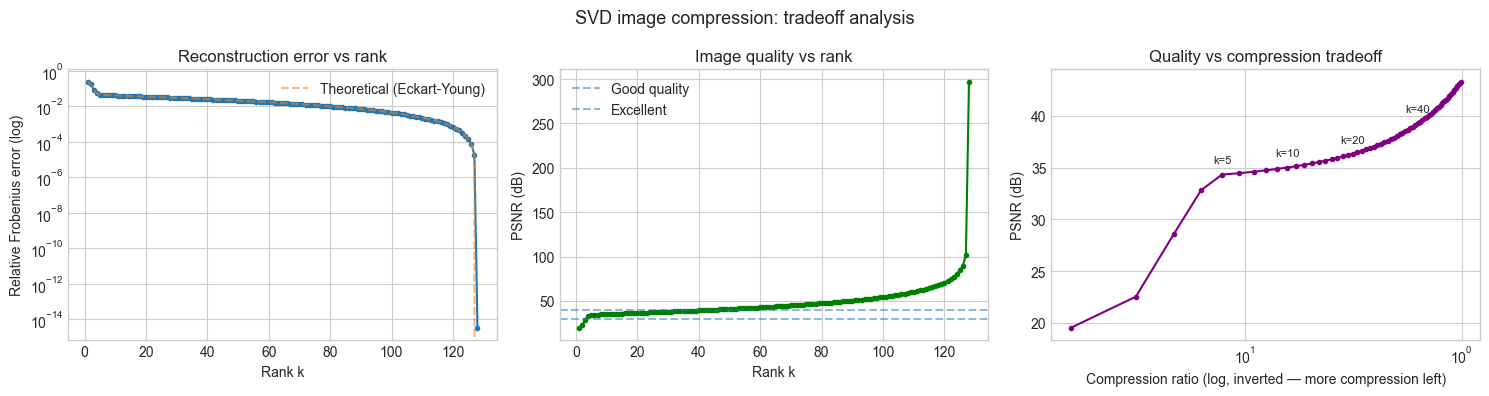

=== Eckart-Young theorem verification ===
The best rank-k approximation in Frobenius norm is the truncated SVD.
Theoretical error ‖M - M_k‖_F = sqrt(sum(s_{k+1}^2 + ...)):
  k=5: theoretical=2.4717, computed=2.4717, match=True
  k=10: theoretical=2.2778, computed=2.2778, match=True
  k=20: theoretical=1.9542, computed=1.9542, match=True


In [6]:
# --- Stage 3: Systematic tradeoff analysis ---
# We now quantify the compression-quality tradeoff precisely.
# This reveals the "elbow" — the rank beyond which more components
# yield diminishing quality improvements.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Relative Frobenius error vs rank
axes[0].semilogy(all_ranks, frobenius_errors, 'o-', markersize=3)
# Theoretical bound: error = sqrt(sum(s[k:]^2)) / ||M||_F
theoretical_errors = [np.sqrt(np.sum(s[k:]**2)) / np.linalg.norm(IMAGE, 'fro') for k in all_ranks]
axes[0].semilogy(all_ranks, theoretical_errors, '--', alpha=0.6, label='Theoretical (Eckart-Young)')
axes[0].set_xlabel('Rank k')
axes[0].set_ylabel('Relative Frobenius error (log)')
axes[0].set_title('Reconstruction error vs rank')
axes[0].legend()

# Plot 2: PSNR vs rank
axes[1].plot(all_ranks, psnr_values, 'o-', markersize=3, color='green')
# Mark the perceptual quality thresholds
for threshold, label in [(30, 'Good quality'), (40, 'Excellent')]: 
    axes[1].axhline(threshold, linestyle='--', alpha=0.5, label=label)
axes[1].set_xlabel('Rank k')
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Image quality vs rank')
axes[1].legend()

# Plot 3: PSNR vs compression ratio (the actual tradeoff)
# Filter to compression ratio > 1 (otherwise we're expanding, not compressing)
valid = np.array(compression_ratios) > 1
axes[2].plot(np.array(compression_ratios)[valid], np.array(psnr_values)[valid], 'o-', markersize=3, color='purple')
axes[2].set_xscale('log')
axes[2].invert_xaxis()
axes[2].set_xlabel('Compression ratio (log, inverted — more compression left)')
axes[2].set_ylabel('PSNR (dB)')
axes[2].set_title('Quality vs compression tradeoff')

# Annotate a few operating points
for k in [5, 10, 20, 40]:
    cr = compression_ratios[k-1]
    if cr > 1:
        axes[2].annotate(f'k={k}', (cr, psnr_values[k-1]), textcoords='offset points',
                         xytext=(0, 8), fontsize=8, ha='center')

plt.suptitle('SVD image compression: tradeoff analysis', fontsize=13)
plt.tight_layout()
plt.show()

# Eckart-Young theorem verification
print("=== Eckart-Young theorem verification ===")
print("The best rank-k approximation in Frobenius norm is the truncated SVD.")
print("Theoretical error ‖M - M_k‖_F = sqrt(sum(s_{k+1}^2 + ...)):")
for k in [5, 10, 20]:
    theoretical = np.sqrt(np.sum(s[k:]**2))
    computed = np.linalg.norm(IMAGE - truncated_svd_reconstruct(U, s, Vt, k), 'fro')
    print(f"  k={k}: theoretical={theoretical:.4f}, computed={computed:.4f}, match={np.isclose(theoretical, computed)}")

## 5. Stage 4 — Color Image Extension

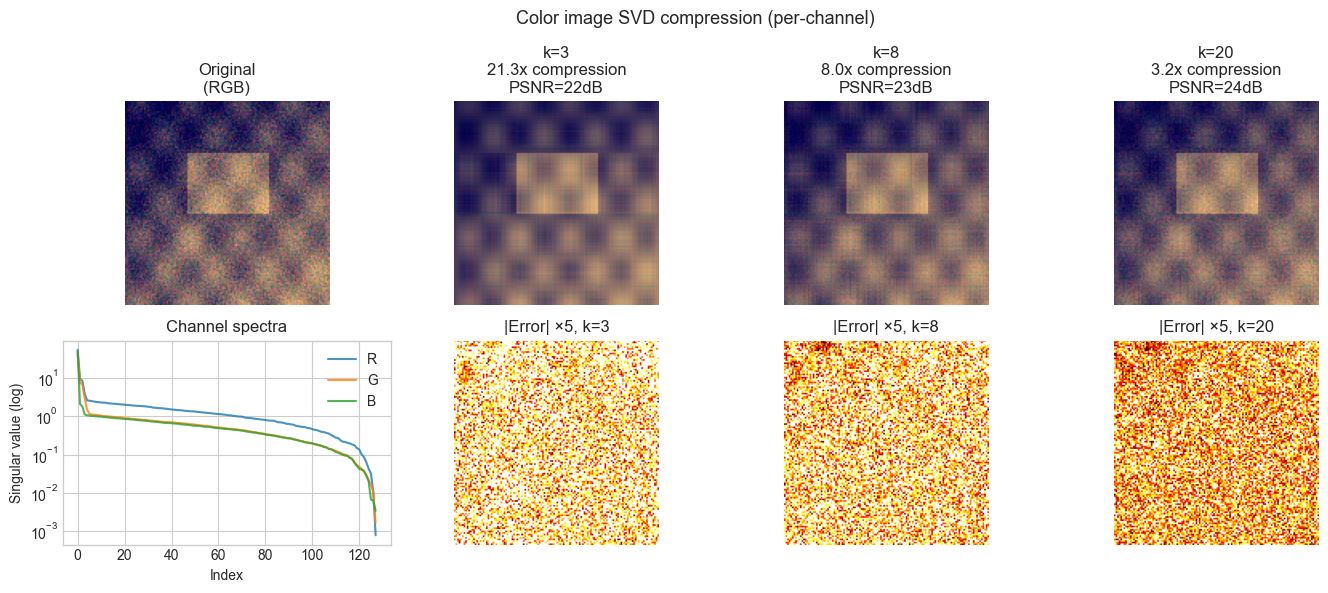

In [8]:
# --- Stage 4: Extend to color images (RGB) ---
# A color image is three matrices (R, G, B channels).
# Apply SVD independently to each channel.
# Compare channel-wise compression to applying SVD on luminance only.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Generate a synthetic color image
def make_color_image(h=128, w=128, seed=42):
    """Generate an RGB image where channels have correlated structure."""
    rng = np.random.default_rng(seed)
    base = make_test_image(h, w, seed=seed)
    R = np.clip(base + 0.1 * rng.standard_normal((h, w)), 0, 1)
    G = np.clip(base * 0.8 + 0.05 * rng.standard_normal((h, w)), 0, 1)
    B = np.clip(0.5 * base + 0.3 * (1 - base) + 0.05 * rng.standard_normal((h, w)), 0, 1)
    return np.stack([R, G, B], axis=-1)  # (h, w, 3)

COLOR_IMG = make_color_image()

def compress_color(img, k):
    """
    Compress each RGB channel independently using rank-k SVD.
    Returns compressed image and total storage cost.
    """
    result = np.zeros_like(img)
    total_stored = 0
    for c in range(3):
        U_c, s_c, Vt_c = np.linalg.svd(img[:, :, c], full_matrices=False)
        result[:, :, c] = np.clip(truncated_svd_reconstruct(U_c, s_c, Vt_c, k), 0, 1)
        total_stored += k * (img.shape[0] + img.shape[1] + 1)
    return result, total_stored

# Compare ranks
K_VALUES = [3, 8, 20]
fig, axes = plt.subplots(2, len(K_VALUES) + 1, figsize=(14, 6))

axes[0, 0].imshow(COLOR_IMG)
axes[0, 0].set_title('Original\n(RGB)')
axes[0, 0].axis('off')

# Show singular value spectra for each channel
for c, (color, label) in enumerate([(COLOR_IMG[:,:,0], 'R'), (COLOR_IMG[:,:,1], 'G'), (COLOR_IMG[:,:,2], 'B')]):
    s_c = np.linalg.svd(color, compute_uv=False)
    axes[1, 0].semilogy(s_c, label=label, alpha=0.8)
axes[1, 0].legend()
axes[1, 0].set_xlabel('Index'); axes[1, 0].set_ylabel('Singular value (log)')
axes[1, 0].set_title('Channel spectra')

original_storage = COLOR_IMG.shape[0] * COLOR_IMG.shape[1] * 3

for col, k in enumerate(K_VALUES):
    compressed, stored = compress_color(COLOR_IMG, k)
    cr = original_storage / stored
    p = psnr(COLOR_IMG, compressed)

    axes[0, col+1].imshow(compressed)
    axes[0, col+1].set_title(f'k={k}\n{cr:.1f}x compression\nPSNR={p:.0f}dB')
    axes[0, col+1].axis('off')

    residual = np.abs(COLOR_IMG - compressed).mean(axis=2)  # mean over channels
    axes[1, col+1].imshow(residual * 5, cmap='hot', vmin=0, vmax=0.3)
    axes[1, col+1].set_title(f'|Error| ×5, k={k}')
    axes[1, col+1].axis('off')

plt.suptitle('Color image SVD compression (per-channel)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Results & Reflection

### What was built

A complete SVD-based image compression pipeline that:
1. Decomposes images into singular components, revealing the spectrum of information
2. Reconstructs at arbitrary rank with guaranteed optimality (Eckart-Young theorem)
3. Quantifies the compression-quality tradeoff using Frobenius error and PSNR
4. Extends to color images by channel-wise decomposition

### What math made it possible

- **SVD (ch173):** The Eckart-Young theorem guarantees that the rank-k truncated SVD is the *best possible* rank-k approximation in the Frobenius norm. No other rank-k matrix is closer to the original.
- **Singular value decay:** Natural image structure (smooth gradients, repeated textures, geometric shapes) creates fast singular value decay — the first few components capture most of the energy. Uniform noise has flat singular value spectra.
- **Rank as information measure (ch175):** The effective rank quantifies how much "independent information" an image contains. Low effective rank = high compressibility.

### Extension challenges

1. **Adaptive rank selection:** Instead of a fixed rank k, choose k automatically so that reconstruction error stays below a user-specified threshold ε. Implement a function `compress_to_quality(image, max_error)` that returns the minimum k satisfying the constraint.

2. **Patch-based compression:** Divide the image into 8×8 or 16×16 patches. Compress each patch independently with SVD. Compare the result to compressing the full image — at the same total storage cost, which gives better PSNR? *(Hint: patches with different content may need different ranks)*

3. **Correlation between color channels:** Instead of compressing each RGB channel independently, first convert to YCbCr (luminance + two chrominance channels). The Y channel carries most perceptual information. Compress Y at high rank and Cb, Cr at low rank. Measure whether this achieves better perceptual quality at the same storage cost.